In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [12]:
df = pd.DataFrame(columns=["Model","Data", "Quality Measure", "k", "Total", "Positive", "Negative"])

for file in os.listdir("./results/"):
    if not file.endswith(".txt") or not file.startswith("SDMapStar_"):
        continue
    file_name = file.split(".txt")[0]
    file_args = file_name.split("_")
    data = file_args[1]
    k = int(file_args[-1])
    if len(file_args) == 4:
        quality = file_args[2]
    else:
        quality = "WRAcc"

    with open(f"./results/{file}", "r") as f:
        lines = f.readlines()
        if lines[0].startswith("WARNING"):
            lines = lines[1:]
        total = float(lines[0].split(": ")[1])
        positive = float(lines[1].split(": ")[1])
        negative = float(lines[2].split(": ")[1])
        df.loc[len(df)] = ["SDMapStar", data, quality, k, total, positive, negative]


In [13]:
df["Youden's J Index"] = df["Positive"] - df["Negative"]

In [14]:
df_d = df[df["Data"] == "Cardio"]
df_d[df_d["Youden's J Index"] == df_d["Youden's J Index"].max()]

,Model,Data,Quality Measure,k,Total,Positive,Negative,Youden's J Index
2,SDMapStar,Cardio,WRAcc,40,0.252857,0.338217,0.167589,0.170628
14,SDMapStar,Cardio,WRAcc,370,0.252857,0.338217,0.167589,0.170628
31,SDMapStar,Cardio,WRAcc,340,0.252857,0.338217,0.167589,0.170628
44,SDMapStar,Cardio,WRAcc,310,0.252857,0.338217,0.167589,0.170628
61,SDMapStar,Cardio,WRAcc,280,0.252857,0.338217,0.167589,0.170628
96,SDMapStar,Cardio,WRAcc,70,0.252857,0.338217,0.167589,0.170628
113,SDMapStar,Cardio,WRAcc,100,0.252857,0.338217,0.167589,0.170628
150,SDMapStar,Cardio,WRAcc,400,0.252857,0.338217,0.167589,0.170628
160,SDMapStar,Cardio,WRAcc,220,0.252857,0.338217,0.167589,0.170628
177,SDMapStar,Cardio,WRAcc,250,0.252857,0.338217,0.167589,0.170628


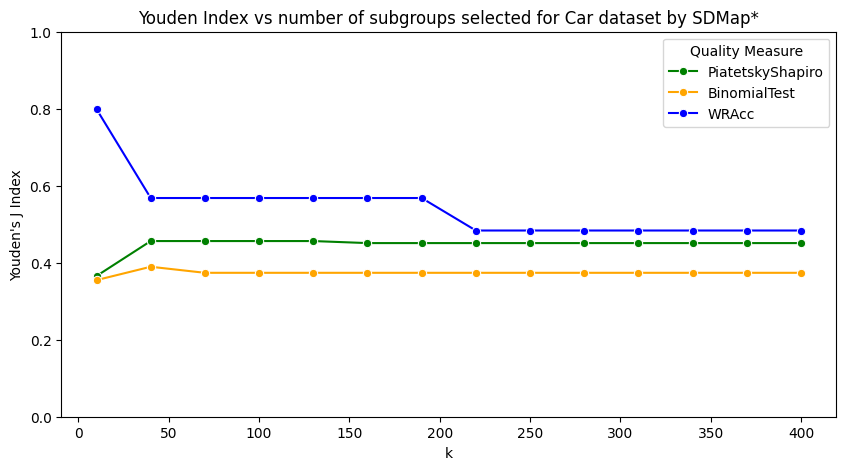

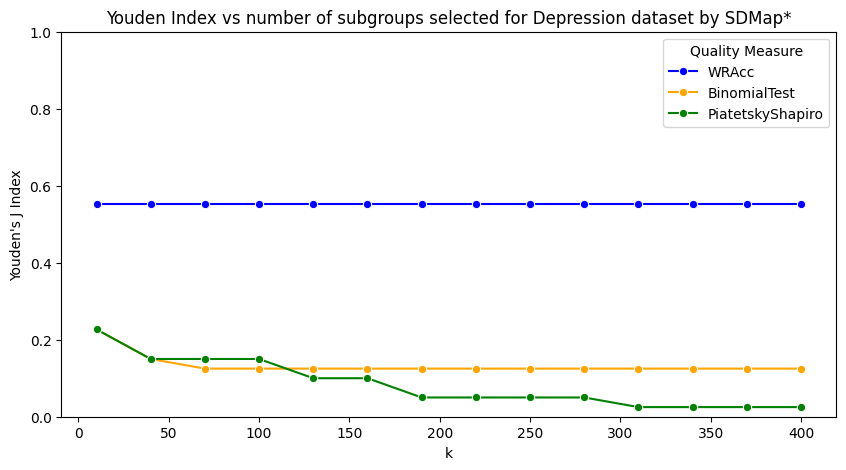

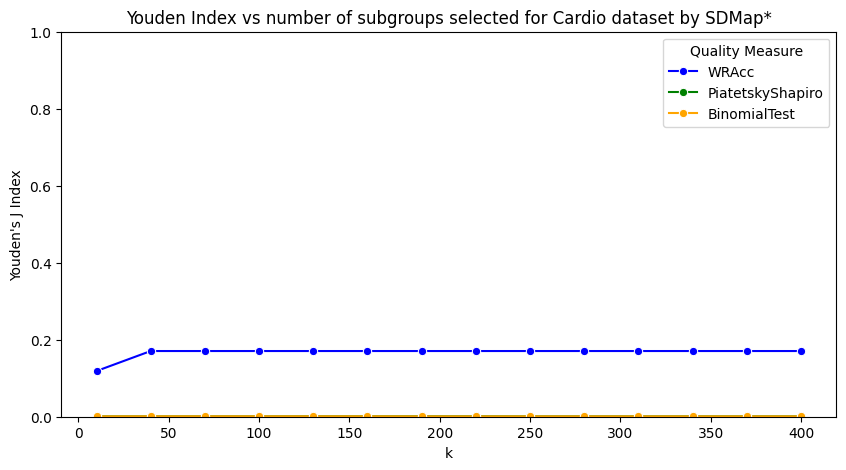

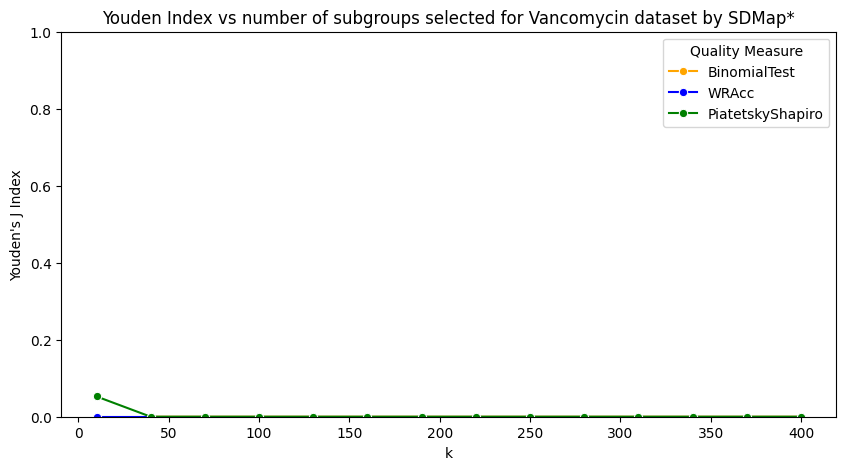

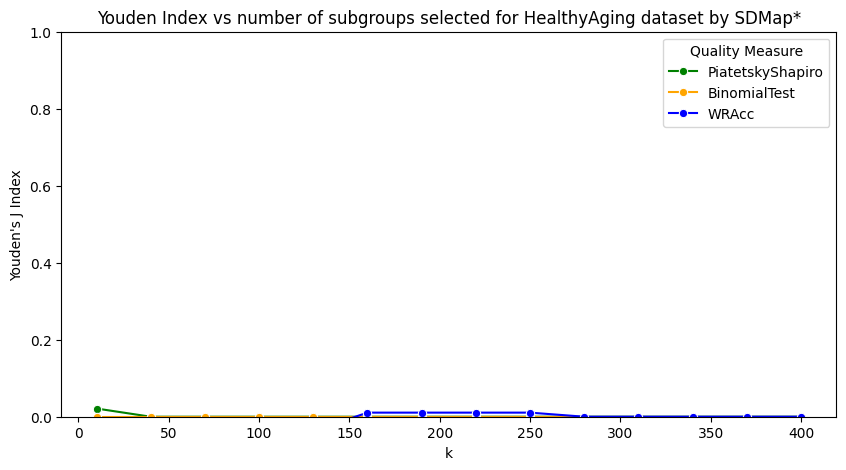

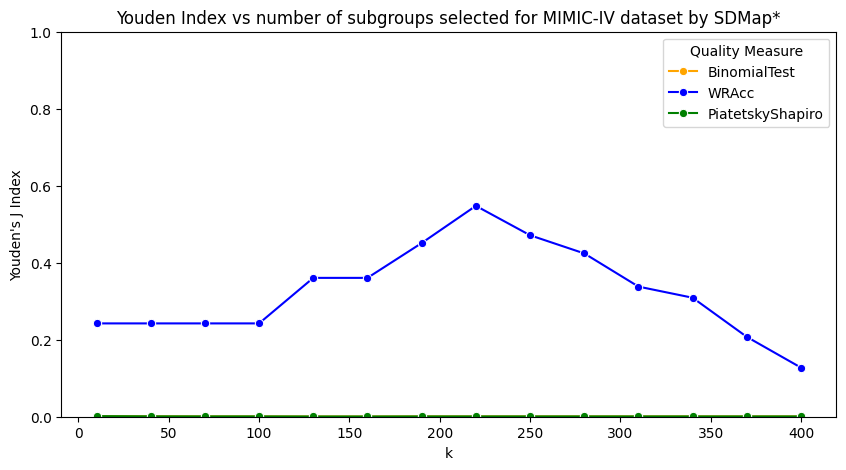

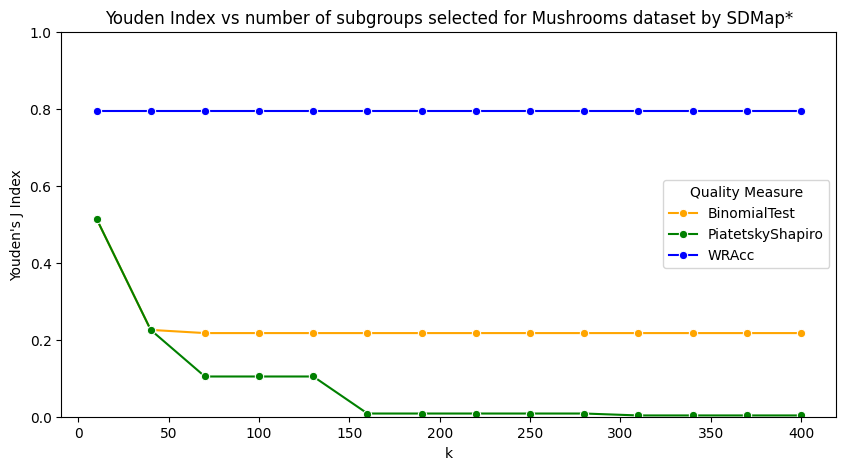

In [15]:
color_map = {
    "WRAcc": "blue",
    "BinomialTest": "orange",
    "PiatetskyShapiro": "green"
}

for d in df["Data"].unique():
    fig = plt.figure(figsize=(10, 5))
    sns.lineplot(x = "k", y = "Youden's J Index", hue = "Quality Measure", data = df[df["Data"] == d], marker="o", palette=color_map)
    plt.title(f"Youden Index vs number of subgroups selected for {d} dataset by SDMap*")
    plt.ylim(0, 1)
    plt.savefig(f"./plots/SDMapStar_{d}_Youden.png")